In [1]:
import sys
import warnings
import itertools
import calendar
from pylab import rcParams
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv('Truck_sales.csv')

In [3]:
df.head()

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223


In [4]:
dates = pd.date_range(start = '1/1/2003', periods=len(df), freq='M')

In [5]:
df['Month'] = dates.month
df['Month'] = df['Month'].apply(lambda x: calendar.month_abbr[x])
df['Year'] = dates.year

In [6]:
df.drop('Month-Year', axis=1, inplace=True)

In [7]:
df.set_index(dates, inplace=True)

In [8]:
df.head()

,Number_Trucks_Sold,Month,Year
2003-01-31,155,Jan,2003
2003-02-28,173,Feb,2003
2003-03-31,204,Mar,2003
2003-04-30,219,Apr,2003
2003-05-31,223,May,2003


In [9]:
df['Truck_Sales'] = df['Number_Trucks_Sold']

In [10]:
df.drop('Number_Trucks_Sold', axis=1, inplace=True)

In [11]:
df.head()

,Month,Year,Truck_Sales
2003-01-31,Jan,2003,155
2003-02-28,Feb,2003,173
2003-03-31,Mar,2003,204
2003-04-30,Apr,2003,219
2003-05-31,May,2003,223


In [12]:
data = df.copy()

In [13]:
sales_ts = data['Truck_Sales']

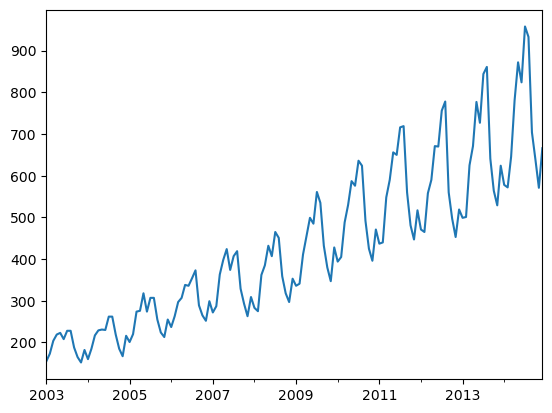

In [14]:
sales_ts.plot()
plt.show();

In [15]:
dftest = adfuller(sales_ts)
dftest[0]

1.1158932574252682

In [16]:
dftest[1]

0.9953500083802601

In [17]:
monthly_sales = data.pivot_table(values = 'Truck_Sales', columns='Year',index='Month')
monthly_sales = monthly_sales.reindex(index=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
monthly_sales

Year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
Month,,,,,,,,,,,,
Jan,155.0,160.0,201.0,237.0,272.0,283.0,336.0,394.0,437.0,471.0,499.0,578.0
Feb,173.0,185.0,220.0,263.0,287.0,275.0,341.0,405.0,440.0,465.0,501.0,572.0
Mar,204.0,217.0,274.0,297.0,363.0,362.0,411.0,488.0,548.0,558.0,625.0,646.0
Apr,219.0,229.0,276.0,307.0,398.0,385.0,455.0,530.0,590.0,590.0,671.0,781.0
May,223.0,231.0,318.0,338.0,424.0,432.0,499.0,587.0,656.0,671.0,777.0,872.0
Jun,208.0,230.0,274.0,336.0,374.0,407.0,485.0,576.0,650.0,670.0,727.0,824.0
Jul,228.0,262.0,307.0,354.0,407.0,465.0,561.0,636.0,716.0,756.0,844.0,958.0
Aug,228.0,262.0,307.0,373.0,419.0,451.0,535.0,624.0,719.0,778.0,861.0,933.0
Sep,188.0,219.0,255.0,289.0,329.0,359.0,432.0,492.0,560.0,560.0,641.0,704.0


In [18]:
yearly_sales = data.pivot_table(values= 'Truck_Sales', index='Year',columns='Month')
yearly_sales = yearly_sales[['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]
yearly_sales

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
2003,155.0,173.0,204.0,219.0,223.0,208.0,228.0,228.0,188.0,165.0,152.0,182.0
2004,160.0,185.0,217.0,229.0,231.0,230.0,262.0,262.0,219.0,185.0,167.0,216.0
2005,201.0,220.0,274.0,276.0,318.0,274.0,307.0,307.0,255.0,224.0,213.0,255.0
2006,237.0,263.0,297.0,307.0,338.0,336.0,354.0,373.0,289.0,265.0,252.0,299.0
2007,272.0,287.0,363.0,398.0,424.0,374.0,407.0,419.0,329.0,293.0,263.0,309.0
2008,283.0,275.0,362.0,385.0,432.0,407.0,465.0,451.0,359.0,318.0,297.0,353.0
2009,336.0,341.0,411.0,455.0,499.0,485.0,561.0,535.0,432.0,380.0,347.0,428.0
2010,394.0,405.0,488.0,530.0,587.0,576.0,636.0,624.0,492.0,425.0,396.0,471.0
2011,437.0,440.0,548.0,590.0,656.0,650.0,716.0,719.0,560.0,481.0,447.0,517.0


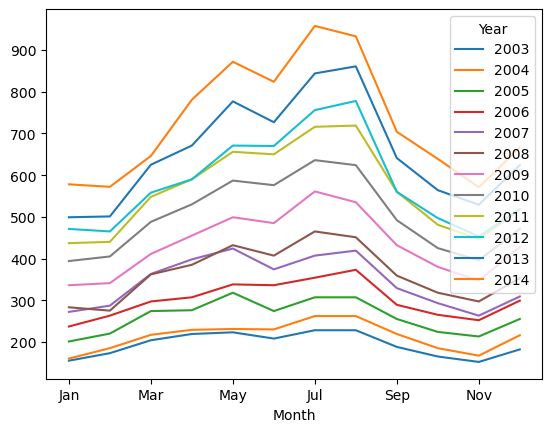

In [19]:
monthly_sales.plot()
plt.show()

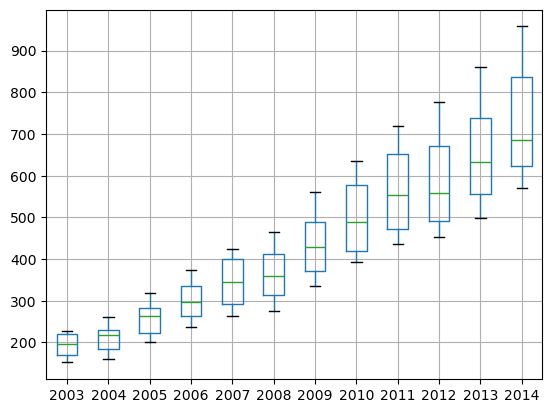

In [20]:
monthly_sales.boxplot()
plt.show()

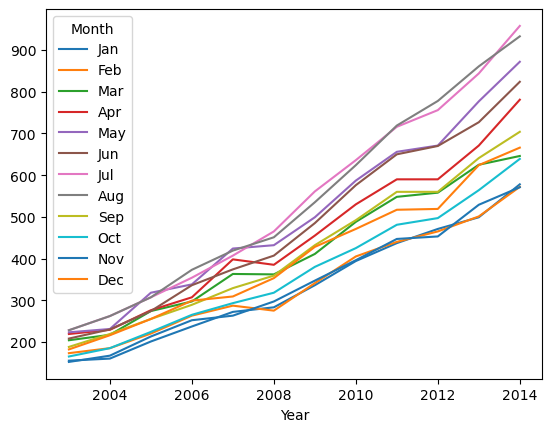

In [21]:
yearly_sales.plot()
plt.show()

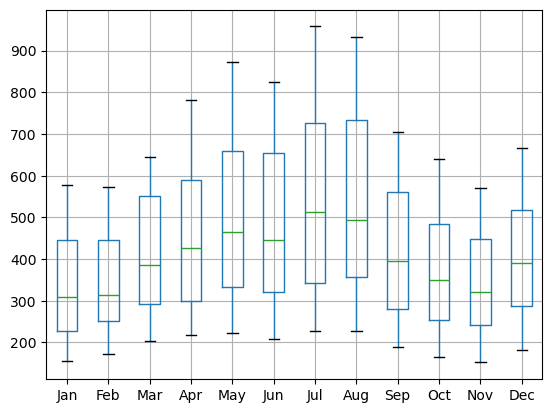

In [22]:
yearly_sales.boxplot()
plt.show()

### Decomposition

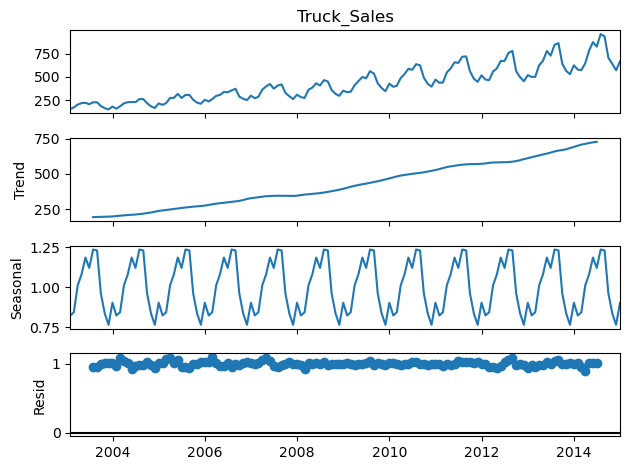

In [23]:
decomposition = sm.tsa.seasonal_decompose(sales_ts, model='multiplicative')
decomposition.plot()
plt.show();

### Defining the pdq estimation matrices

In [24]:
p = range(1,4)
d = range(0,2)
q = range(1,4)
pdq_ar = list(itertools.product(p, range(1), range(1)))
pdq_arma = list(itertools.product(p, range(1), q))
pdq_arima = list(itertools.product(p,d,q))
pdq_sarima = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p,d,q))]

In [25]:
pdq_ar

[(1, 0, 0), (2, 0, 0), (3, 0, 0)]

In [26]:
pdq_arma

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3)]

In [27]:
pdq_arima

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3)]

In [28]:
pdq_sarima

[(1, 0, 1, 12),
 (1, 0, 2, 12),
 (1, 0, 3, 12),
 (1, 1, 1, 12),
 (1, 1, 2, 12),
 (1, 1, 3, 12),
 (2, 0, 1, 12),
 (2, 0, 2, 12),
 (2, 0, 3, 12),
 (2, 1, 1, 12),
 (2, 1, 2, 12),
 (2, 1, 3, 12),
 (3, 0, 1, 12),
 (3, 0, 2, 12),
 (3, 0, 3, 12),
 (3, 1, 1, 12),
 (3, 1, 2, 12),
 (3, 1, 3, 12)]

### Train Test Split

In [29]:
train = data[0:int(len(data)*0.75)]
test = data[int(len(data)*0.75):]

#### Using log transformation for variance

In [30]:
train_sales_log = np.log10(train['Truck_Sales'])

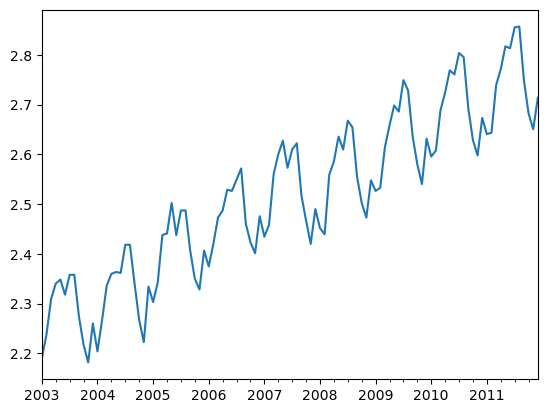

In [31]:
train_sales_log.plot()
plt.show();

### AR Model

In [32]:
ar_aic = pd.DataFrame(columns = ['param','AIC'])
ar_aic

,param,AIC


In [33]:
for param in pdq_ar:
    AR_model = ARIMA(train_sales_log, order=param).fit()
    ar_aic = pd.concat([ar_aic,pd.DataFrame({'param':[param],'AIC':[AR_model.aic]})],ignore_index=True)

In [34]:
ar_aic = ar_aic.sort_values(by='AIC')
ar_aic

,param,AIC
1,"(2, 0, 0)",-312.637619
0,"(1, 0, 0)",-312.337287
2,"(3, 0, 0)",-310.640184


In [35]:
best_results_ar = ARIMA(train_sales_log, order=(2,0,0)).fit()
print(best_results_ar.summary().tables[0])
print(best_results_ar.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:            Truck_Sales   No. Observations:                  108
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 160.319
Date:                Wed, 30 Apr 2025   AIC                           -312.638
Time:                        21:02:14   BIC                           -301.909
Sample:                    01-31-2003   HQIC                          -308.288
                         - 12-31-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5029      0.078     32.289      0.000       2.351       2.655
ar.L1          1.0948      0.128      8.527      0.000       0.843       1.346
ar.L2         -0.1478      0.128     -1.158      0.2

In [36]:
pred_dynamic_ar = best_results_ar.get_prediction(start=test.index[0], dynamic = True, full_results=True)
pred95_ar = best_results_ar.get_forecast(steps=len(test), alpha=0.05)
sales_ts_forecasted = pred_dynamic_ar.predicted_mean
testcopy_ar = test.copy()
testcopy_ar['sales_ts_forecasted'] = np.power(10, pred95_ar.predicted_mean)

In [37]:
mse_ar = ((testcopy_ar['Truck_Sales'] - testcopy_ar['sales_ts_forecasted'])**2).mean()
rmse_ar = np.sqrt(mse_ar)
rmse_ar

312.38393016518233

In [38]:
resultsdf = pd.DataFrame({'Model':['AR(2,0,0)'],'RMSE':[rmse_ar]})
resultsdf

,Model,RMSE
0,"AR(2,0,0)",312.38393


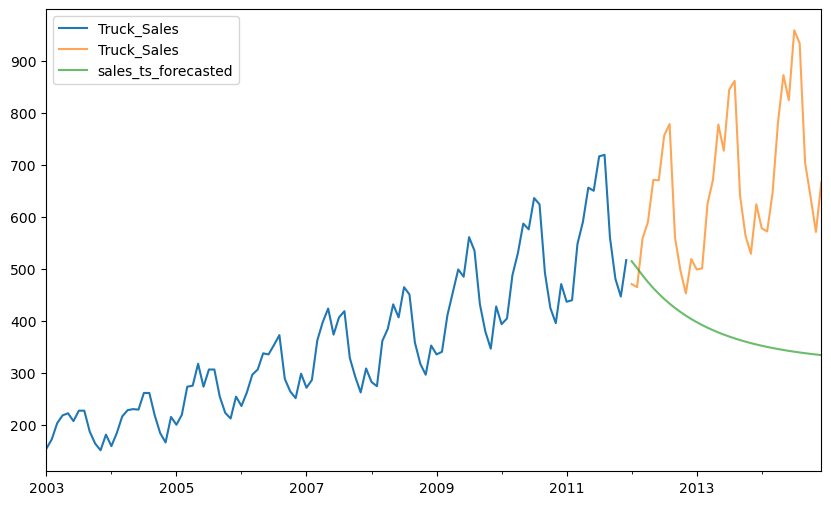

In [39]:
axis = train['Truck_Sales'].plot(legend = 'Train Sales', figsize=(10,6))
testcopy_ar['Truck_Sales'].plot(ax=axis, legend='Test Sales', alpha=0.7)
testcopy_ar['sales_ts_forecasted'].plot(ax=axis, legend='Forecasted Sales', alpha=0.7)
plt.legend()
plt.show();

### ARMA Model 

In [40]:
arma_aic = pd.DataFrame(columns=['param','AIC'])
arma_aic

,param,AIC


In [41]:
for param in pdq_arma:
    ARMA_model = ARIMA(train_sales_log, order=param).fit()
    arma_aic = pd.concat([arma_aic,pd.DataFrame({'param':[param],'AIC':[ARMA_model.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [42]:
arma_aic = arma_aic.sort_values(by='AIC')
arma_aic

,param,AIC
8,"(3, 0, 3)",-338.530775
7,"(3, 0, 2)",-322.940499
2,"(1, 0, 3)",-318.730986
6,"(3, 0, 1)",-312.861644
4,"(2, 0, 2)",-312.859163
0,"(1, 0, 1)",-312.596870
5,"(2, 0, 3)",-311.410105
1,"(1, 0, 2)",-310.651449
3,"(2, 0, 1)",-310.639767


In [43]:
best_results_arma = ARIMA(train_sales_log, order=(3,0,3)).fit()
print(best_results_arma.summary().tables[0])
print(best_results_arma.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:            Truck_Sales   No. Observations:                  108
Model:                 ARIMA(3, 0, 3)   Log Likelihood                 177.265
Date:                Wed, 30 Apr 2025   AIC                           -338.531
Time:                        21:02:16   BIC                           -317.074
Sample:                    01-31-2003   HQIC                          -329.831
                         - 12-31-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4628     65.240      0.038      0.970    -125.405     130.331
ar.L1         -0.6807      0.034    -20.054      0.000      -0.747      -0.614
ar.L2          0.7155      0.018     40.403      0.0

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [44]:
pred_dynamic_arma = best_results_arma.get_prediction(start = test.index[0], dynamic=True, full_results=True)
pred95_arma = best_results_arma.get_forecast(steps=len(test), alpha=0.05)
sales_ts_forecasted_arma = pred_dynamic_arma.predicted_mean
testcopy_arma = test.copy()
testcopy_arma['sales_ts_forecasted_arma'] = np.power(10, pred95_arma.predicted_mean)

In [45]:
mse_arma = ((testcopy_arma['Truck_Sales'] - testcopy_arma['sales_ts_forecasted_arma'])**2).mean()
rmse_arma = np.sqrt(mse_arma)
rmse_arma

193.2437395007536

In [46]:
results_arma = pd.DataFrame({'Model':['ARMA(3,0,3)'],'RMSE':[rmse_arma]})
resultsdf = pd.concat([resultsdf, results_arma],ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(2,0,0)",312.38393
1,"ARMA(3,0,3)",193.24374


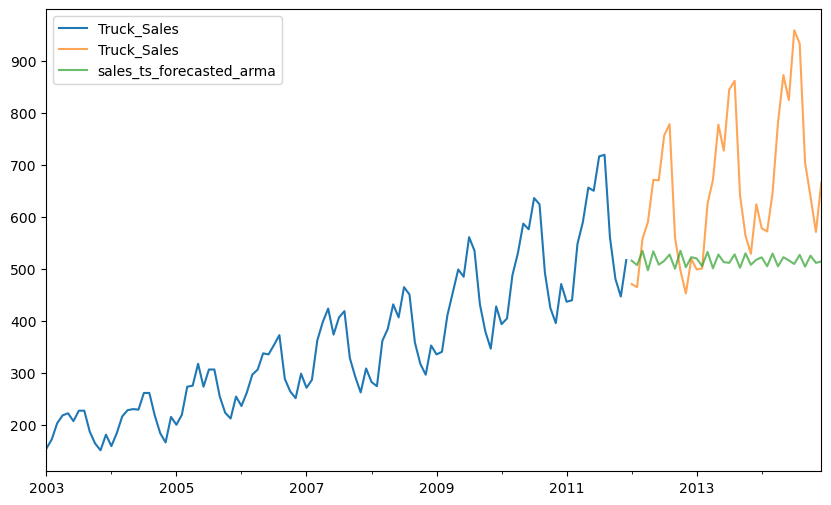

In [47]:
axis = train['Truck_Sales'].plot(legend='Train Sales', figsize = (10,6))
testcopy_arma['Truck_Sales'].plot(ax=axis, legend='Test Sales', alpha=0.7)
testcopy_arma['sales_ts_forecasted_arma'].plot(ax=axis, legend='Forecasted Sales', alpha=0.7)
plt.legend()
plt.show();

### ARIMA Model

In [48]:
arima_aic = pd.DataFrame(columns=['param','AIC'])
arima_aic

,param,AIC


In [49]:
for param in pdq_arima:
    ARIMA_model = ARIMA(train_sales_log, order=param).fit()
    arima_aic = pd.concat([arima_aic, pd.DataFrame({'param':[param],'AIC':[ARIMA_model.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: C

In [50]:
arima_aic = arima_aic.sort_values(by='AIC')
arima_aic.head()

,param,AIC
16,"(3, 1, 2)",-354.907546
14,"(3, 0, 3)",-338.530775
10,"(2, 1, 2)",-337.379139
17,"(3, 1, 3)",-335.454828
13,"(3, 0, 2)",-322.940499


In [51]:
best_results_arima = ARIMA(train_sales_log, order=(3,0,3)).fit()
print(best_results_arima.summary().tables[0])
print(best_results_arima.summary().tables[1])

                               SARIMAX Results                                
Dep. Variable:            Truck_Sales   No. Observations:                  108
Model:                 ARIMA(3, 0, 3)   Log Likelihood                 177.265
Date:                Wed, 30 Apr 2025   AIC                           -338.531
Time:                        21:02:20   BIC                           -317.074
Sample:                    01-31-2003   HQIC                          -329.831
                         - 12-31-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4628     65.240      0.038      0.970    -125.405     130.331
ar.L1         -0.6807      0.034    -20.054      0.000      -0.747      -0.614
ar.L2          0.7155      0.018     40.403      0.0

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [52]:
pred_dynamic_arima = best_results_arima.get_prediction(start = test.index[0], dynamic=True, full_results=True)
pred95_arima = best_results_arima.get_forecast(steps=len(test), alpha=0.7)
sales_ts_forecasted_arima = pred_dynamic_arima.predicted_mean
testcopy_arima = test.copy()
testcopy_arima['sales_ts_forecasted_arima']= np.power(10, pred95_arima.predicted_mean)

In [53]:
mse_arima = ((testcopy_arima['Truck_Sales'] - testcopy_arima['sales_ts_forecasted_arima'])**2).mean()
rmse_arima = np.sqrt(mse_arima)
rmse_arima

193.2437395007536

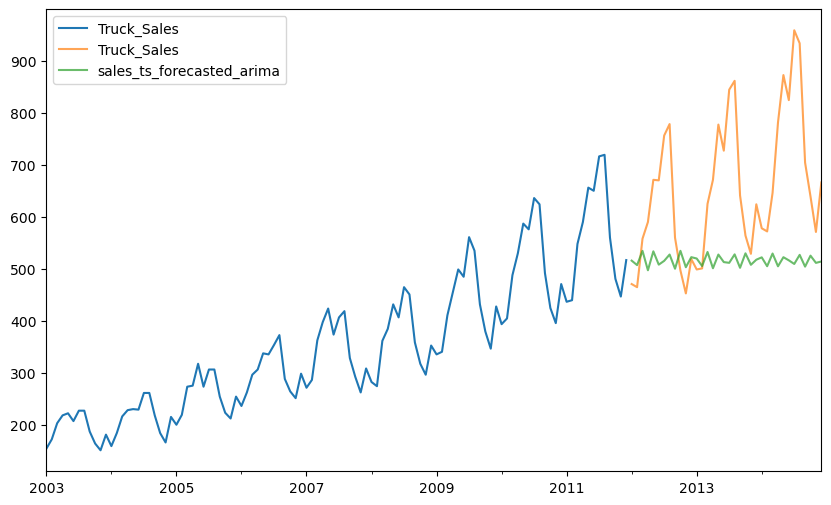

In [54]:
axis = train['Truck_Sales'].plot(legend = 'Train Sales',figsize = (10,6))
testcopy_arima['Truck_Sales'].plot(ax=axis, legend='Test Sales', alpha=0.7)
testcopy_arima['sales_ts_forecasted_arima'].plot(ax=axis, legend='Forecasted Sales', alpha=0.7)
plt.legend()
plt.show();

In [55]:
results_arima = pd.DataFrame({'Model':['ARIMA(3,0,3)'],'RMSE':[rmse_arima]})
resultsdf = pd.concat([resultsdf, results_arima],ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(2,0,0)",312.38393
1,"ARMA(3,0,3)",193.24374
2,"ARIMA(3,0,3)",193.24374


### SARIMA Model

In [56]:
sarima_aic = pd.DataFrame(columns=['param','seasonal','AIC'])
sarima_aic

,param,seasonal,AIC


In [57]:
for param in pdq_arima:
    for seasonal_param in pdq_sarima:
        SARIMA_model = sm.tsa.statespace.SARIMAX(train_sales_log,
                                                 order=param,
                                                 seasonal_order=seasonal_param,
                                                 enforce_stationarity=False,
                                                 enforce_invertibility=False).fit(maxiter=1000)
        sarima_aic = pd.concat([sarima_aic,pd.DataFrame({'param':[param],'seasonal':[seasonal_param],'AIC':[SARIMA_model.aic]})],ignore_index=True)

C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Hrishikesh\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: C

In [58]:
sarima_aic = sarima_aic.sort_values(by='AIC')
sarima_aic.head()

,param,seasonal,AIC
0,"(1, 0, 1)","(1, 0, 1, 12)",-497.229208
108,"(2, 0, 1)","(1, 0, 1, 12)",-495.888222
234,"(3, 0, 2)","(1, 0, 1, 12)",-488.971229
18,"(1, 0, 2)","(1, 0, 1, 12)",-488.856034
216,"(3, 0, 1)","(1, 0, 1, 12)",-487.557781


In [59]:
best_results_sarima = sm.tsa.statespace.SARIMAX(train_sales_log,
                                                order = (1,0,1),
                                                seasonal_order = (1,0,1,12),
                                                enforce_stationarity=True).fit(maxiter=1000)
print(best_results_sarima.summary().tables[0])
print(best_results_sarima.summary().tables[1])

                                     SARIMAX Results                                      
Dep. Variable:                        Truck_Sales   No. Observations:                  108
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                 269.534
Date:                            Wed, 30 Apr 2025   AIC                           -529.068
Time:                                    21:20:16   BIC                           -515.658
Sample:                                01-31-2003   HQIC                          -523.631
                                     - 12-31-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9966      0.005    207.441      0.000       0.987       1.006
ma.L1         -0.3207      0.088   

In [60]:
pred_dynamic_sarima = best_results_sarima.get_prediction(start=test.index[0], dynamic=True, full_results=True)
pred95_sarima = best_results_sarima.get_forecast(steps=len(test), alpha=0.05)
sales_ts_forecasted_sarima = pred_dynamic_sarima.predicted_mean
testcopy_sarima = test.copy()
testcopy_sarima['sales_ts_forecasted_sarima'] = np.power(10, pred95_sarima.predicted_mean)

In [61]:
mse_sarima = ((testcopy_sarima['Truck_Sales'] - testcopy_sarima['sales_ts_forecasted_sarima'])**2).mean()
rmse_sarima = np.sqrt(mse_sarima)
rmse_sarima

32.345465762713836

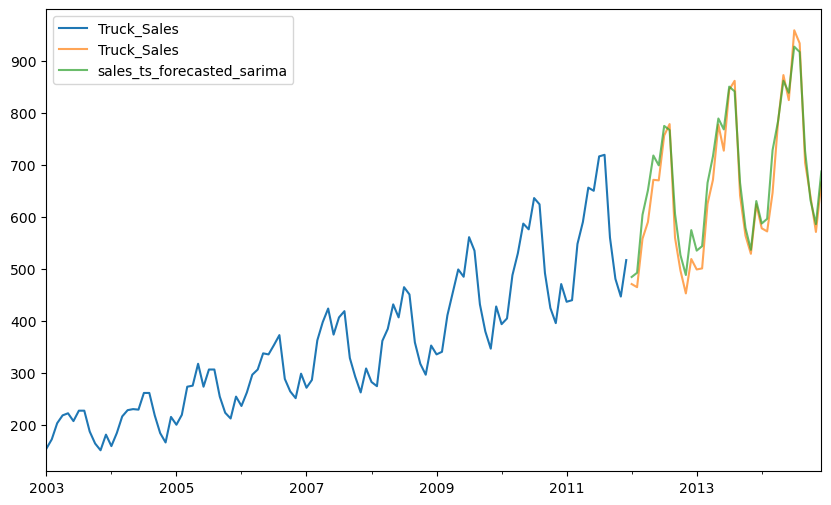

In [62]:
axis = train['Truck_Sales'].plot(legend='Train Sales', figsize = (10,6))
testcopy_sarima['Truck_Sales'].plot(ax=axis, legend='Test Sales', alpha=0.7)
testcopy_sarima['sales_ts_forecasted_sarima'].plot(ax=axis,legend='Forecasted Sales', alpha=0.7)
plt.legend()
plt.show()

In [63]:
results_sarima = pd.DataFrame({'Model':['SARIMA(1,0,1)(1,0,1,12)'],'RMSE':[rmse_sarima]})
resultsdf = pd.concat([resultsdf, results_sarima],ignore_index=True)
resultsdf

,Model,RMSE
0,"AR(2,0,0)",312.383930
1,"ARMA(3,0,3)",193.243740
2,"ARIMA(3,0,3)",193.243740
3,"SARIMA(1,0,1)(1,0,1,12)",32.345466


## Final Model Selection - SARIMA

In [64]:
n_steps = 36
pred_uc_99 = best_results_sarima.get_forecast(steps = 36, alpha = 0.01)
pred_uc_95 = best_results_sarima.get_forecast(steps = 36, alpha = 0.05)
pred_ci_99 = pred_uc_99.conf_int()
pred_ci_95 = pred_uc_95.conf_int()

In [65]:
data.tail()

,Month,Year,Truck_Sales
2014-08-31,Aug,2014,933
2014-09-30,Sep,2014,704
2014-10-31,Oct,2014,639
2014-11-30,Nov,2014,571
2014-12-31,Dec,2014,666


In [66]:
n_steps = 36
idx = pd.date_range(start='1/1/2015', periods = 36, freq='M')
fc_95 = pd.DataFrame(np.column_stack([np.power(10, pred_uc_95.predicted_mean),np.power(10,pred_ci_95)]),index=idx,
                                     columns=['Forecast','Lower_CI_95','Upper_CI_95'])
fc_99 = pd.DataFrame(np.column_stack([np.power(10, pred_ci_99)]), index=idx, columns = ['Lower_CI_99','Upper_CI_99'])
fc = fc_95.combine_first(fc_99)
fc = fc[['Forecast','Lower_CI_95','Upper_CI_95','Lower_CI_99','Upper_CI_99']]
fc.head()

,Forecast,Lower_CI_95,Upper_CI_95,Lower_CI_99,Upper_CI_99
2015-01-31,484.566848,450.305988,521.434394,450.305988,521.434394
2015-02-28,492.636402,450.909962,538.224136,450.909962,538.224136
2015-03-31,603.865902,545.662873,668.277146,545.662873,668.277146
2015-04-30,650.821525,581.473934,728.439629,581.473934,728.439629
2015-05-31,717.656654,634.672117,811.491570,634.672117,811.491570


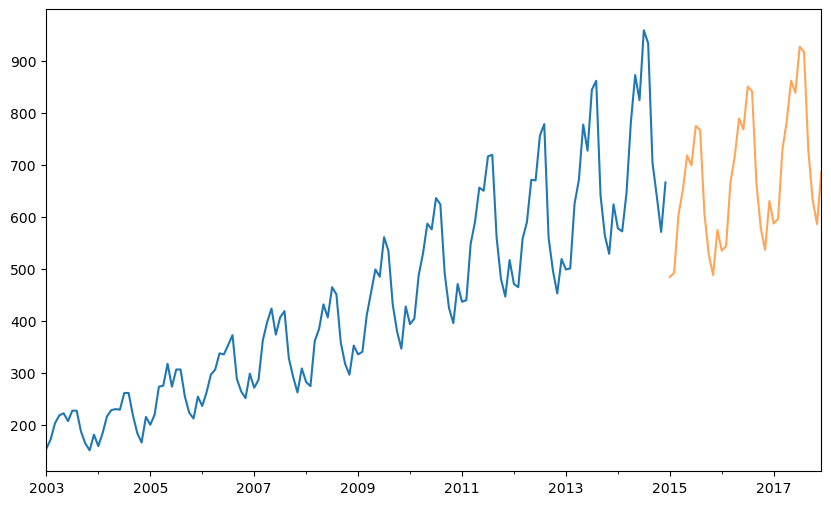

In [67]:
axis=sales_ts.plot(figsize=(10,6))
fc['Forecast'].plot(ax=axis, alpha=0.7)
plt.show();

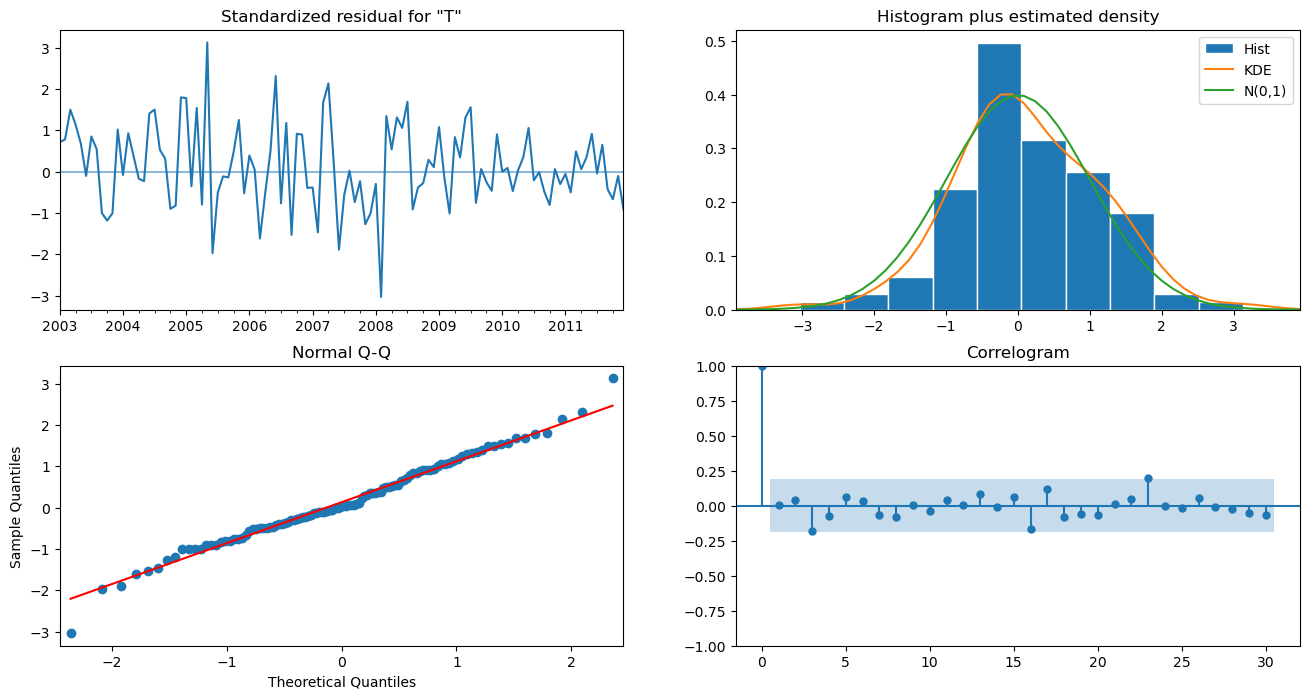

In [68]:
best_results_sarima.plot_diagnostics(lags=30, figsize=(16,8))
plt.show();